<a href="https://colab.research.google.com/github/rikiatzori/DL/blob/W1D3/tutorials/W1D3_MultiLayerPerceptrons/student/W1D3_Tutorial1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 1: Biological vs. Artificial Neural Networks

**Week 1, Day 3: Multi Layer Perceptrons**

**By Neuromatch Academy**

__Content creators:__ Arash Ash, Surya Ganguli

__Content reviewers:__ Saeed Salehi, Felix Bartsch, Yu-Fang Yang, Antoine De Comite, Melvin Selim Atay, Kelson Shilling-Scrivo

__Content editors:__ Gagana B, Kelson Shilling-Scrivo, Spiros Chavlis

__Production editors:__ Anoop Kulkarni, Kelson Shilling-Scrivo, Gagana B, Spiros Chavlis

---
# Tutorial objectives

In this tutorial, we will explore the Multi-layer Perceptrons (MLPs). MLPs are arguably one of the most tractable models (due to their flexibility) that we can use to study deep learning fundamentals. Here we will learn why they are:

* Similar to biological networks
* Good at function approximation
* Implemented the way they are in PyTorch

In [12]:
# @title Tutorial slides
from IPython.display import IFrame
link_id = "4ye56"
print(f"If you want to download the slides: https://osf.io/download/{link_id}/")
IFrame(src=f"https://mfr.ca-1.osf.io/render?url=https://osf.io/{link_id}/?direct%26mode=render%26action=download%26mode=render", width=854, height=480)

If you want to download the slides: https://osf.io/download/4ye56/


---
# Setup

This is a GPU free notebook!

In [13]:
# @title Install and import feedback gadget

!pip3 install vibecheck datatops --quiet

from vibecheck import DatatopsContentReviewContainer
def content_review(notebook_section: str):
    return DatatopsContentReviewContainer(
        "",  # No text prompt
        notebook_section,
        {
            "url": "https://pmyvdlilci.execute-api.us-east-1.amazonaws.com/klab",
            "name": "neuromatch_dl",
            "user_key": "f379rz8y",
        },
    ).render()


feedback_prefix = "W1D3_T1"

In [14]:
# Imports
import random

import torch
import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
from IPython.display import display
from torch.utils.data import DataLoader, TensorDataset

In [15]:
# @title Figure settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

import ipywidgets as widgets  # Interactive display
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/content-creation/main/nma.mplstyle")

In [16]:
# @title Plotting functions

def imshow(img):
  """
  Helper function to plot unnormalised image

  Args:
    img: torch.tensor
      Image to be displayed

  Returns:
    Nothing
  """
  img = img / 2 + 0.5  # Unnormalize
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))
  plt.axis(False)
  plt.show()


def plot_function_approximation(x, relu_acts, y_hat):
  """
  Helper function to plot ReLU activations and
  function approximations

  Args:
    x: torch.tensor
      Incoming Data
    relu_acts: torch.tensor
      Computed ReLU activations for each point along the x axis (x)
    y_hat: torch.tensor
      Estimated labels/class predictions
      Weighted sum of ReLU activations for every point along x axis

  Returns:
    Nothing
  """
  fig, axes = plt.subplots(2, 1)

  # Plot ReLU Activations
  axes[0].plot(x, relu_acts.T);
  axes[0].set(xlabel='x',
              ylabel='Activation',
              title='ReLU Activations - Basis Functions')
  labels = [f"ReLU {i + 1}" for i in range(relu_acts.shape[0])]
  axes[0].legend(labels, ncol = 2)

  # Plot Function Approximation
  axes[1].plot(x, torch.sin(x), label='truth')
  axes[1].plot(x, y_hat, label='estimated')
  axes[1].legend()
  axes[1].set(xlabel='x',
              ylabel='y(x)',
              title='Function Approximation')

  plt.tight_layout()
  plt.show()

In [17]:
# @title Set random seed

# @markdown Executing `set_seed(seed=seed)` you are setting the seed

# For DL its critical to set the random seed so that students can have a
# baseline to compare their results to expected results.
# Read more here: https://pytorch.org/docs/stable/notes/randomness.html

# Call `set_seed` function in the exercises to ensure reproducibility.
import random
import torch

def set_seed(seed=None, seed_torch=True):
  """
  Function that controls randomness. NumPy and random modules must be imported.

  Args:
    seed : Integer
      A non-negative integer that defines the random state. Default is `None`.
    seed_torch : Boolean
      If `True` sets the random seed for pytorch tensors, so pytorch module
      must be imported. Default is `True`.

  Returns:
    Nothing.
  """
  if seed is None:
    seed = np.random.choice(2 ** 32)
  random.seed(seed)
  np.random.seed(seed)
  if seed_torch:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

  print(f'Random seed {seed} has been set.')


# In case that `DataLoader` is used
def seed_worker(worker_id):
  """
  DataLoader will reseed workers following randomness in
  multi-process data loading algorithm.

  Args:
    worker_id: integer
      ID of subprocess to seed. 0 means that
      the data will be loaded in the main process
      Refer: https://pytorch.org/docs/stable/data.html#data-loading-randomness for more details

  Returns:
    Nothing
  """
  worker_seed = torch.initial_seed() % 2**32
  np.random.seed(worker_seed)
  random.seed(worker_seed)

In [18]:
# @title Set device (GPU or CPU). Execute `set_device()`
# especially if torch modules used.

# Inform the user if the notebook uses GPU or CPU.
# NOTE: This is mostly a GPU free tutorial.

def set_device():
  """
  Set the device. CUDA if available, CPU otherwise

  Args:
    None

  Returns:
    Nothing
  """
  device = "cuda" if torch.cuda.is_available() else "cpu"
  if device != "cuda":
    print("GPU is not enabled in this notebook. \n"
          "If you want to enable it, in the menu under `Runtime` -> \n"
          "`Hardware accelerator.` and select `GPU` from the dropdown menu")
  else:
    print("GPU is enabled in this notebook. \n"
          "If you want to disable it, in the menu under `Runtime` -> \n"
          "`Hardware accelerator.` and select `None` from the dropdown menu")

  return device

In [19]:
SEED = 2021
set_seed(seed=SEED)
DEVICE = set_device()

Random seed 2021 has been set.
GPU is not enabled in this notebook. 
If you want to enable it, in the menu under `Runtime` -> 
`Hardware accelerator.` and select `GPU` from the dropdown menu


---
# Section 0: Introduction to MLPs

In [20]:
# @title Video 0: Introduction
from ipywidgets import widgets
from IPython.display import YouTubeVideo
from IPython.display import IFrame
from IPython.display import display


class PlayVideo(IFrame):
  def __init__(self, id, source, page=1, width=400, height=300, **kwargs):
    self.id = id
    if source == 'Bilibili':
      src = f'https://player.bilibili.com/player.html?bvid={id}&page={page}'
    elif source == 'Osf':
      src = f'https://mfr.ca-1.osf.io/render?url=https://osf.io/download/{id}/?direct%26mode=render'
    super(PlayVideo, self).__init__(src, width, height, **kwargs)


def display_videos(video_ids, W=400, H=300, fs=1):
  tab_contents = []
  for i, video_id in enumerate(video_ids):
    out = widgets.Output()
    with out:
      if video_ids[i][0] == 'Youtube':
        video = YouTubeVideo(id=video_ids[i][1], width=W,
                             height=H, fs=fs, rel=0)
        print(f'Video available at https://youtube.com/watch?v={video.id}')
      else:
        video = PlayVideo(id=video_ids[i][1], source=video_ids[i][0], width=W,
                          height=H, fs=fs, autoplay=False)
        if video_ids[i][0] == 'Bilibili':
          print(f'Video available at https://www.bilibili.com/video/{video.id}')
        elif video_ids[i][0] == 'Osf':
          print(f'Video available at https://osf.io/{video.id}')
      display(video)
    tab_contents.append(out)
  return tab_contents


video_ids = [('Youtube', 'Gh0KYl7ViAc'), ('Bilibili', 'BV1E3411r7TL')]
tab_contents = display_videos(video_ids, W=854, H=480)
tabs = widgets.Tab()
tabs.children = tab_contents
for i in range(len(tab_contents)):
  tabs.set_title(i, video_ids[i][0])
display(tabs)

In [21]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Introduction_Video")

---
# Section 1: The Need for MLPs

*Time estimate: ~35 mins*

In [ ]:
# @title Video 1: Universal Approximation Theorem
from ipywidgets import widgets
from IPython.display import YouTubeVideo
from IPython.display import IFrame
from IPython.display import display


class PlayVideo(IFrame):
  def __init__(self, id, source, page=1, width=400, height=300, **kwargs):
    self.id = id
    if source == 'Bilibili':
      src = f'https://player.bilibili.com/player.html?bvid={id}&page={page}'
    elif source == 'Osf':
      src = f'https://mfr.ca-1.osf.io/render?url=https://osf.io/download/{id}/?direct%26mode=render'
    super(PlayVideo, self).__init__(src, width, height, **kwargs)


def display_videos(video_ids, W=400, H=300, fs=1):
  tab_contents = []
  for i, video_id in enumerate(video_ids):
    out = widgets.Output()
    with out:
      if video_ids[i][0] == 'Youtube':
        video = YouTubeVideo(id=video_ids[i][1], width=W,
                             height=H, fs=fs, rel=0)
        print(f'Video available at https://youtube.com/watch?v={video.id}')
      else:
        video = PlayVideo(id=video_ids[i][1], source=video_ids[i][0], width=W,
                          height=H, fs=fs, autoplay=False)
        if video_ids[i][0] == 'Bilibili':
          print(f'Video available at https://www.bilibili.com/video/{video.id}')
        elif video_ids[i][0] == 'Osf':
          print(f'Video available at https://osf.io/{video.id}')
      display(video)
    tab_contents.append(out)
  return tab_contents


video_ids = [('Youtube', 'tg8HHKo1aH4'), ('Bilibili', 'BV1SP4y147Uv')]
tab_contents = display_videos(video_ids, W=854, H=480)
tabs = widgets.Tab()
tabs.children = tab_contents
for i in range(len(tab_contents)):
  tabs.set_title(i, video_ids[i][0])
display(tabs)

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Universal_Approximation_Theorem_Video")

## Coding Exercise 1: Function approximation with ReLU
Through the Universal Approximation Algorithm, we learned that one hidden layer MLPs are enough to approximate any smooth function! Now let's manually fit a sine function using ReLU activation.

We will approximate the sine function using a linear combination (a weighted sum) of ReLUs with slope 1. We need to determine the bias terms (which determines where the ReLU inflection point from 0 to linear occurs) and how to weight each ReLU. The idea is to set the weights iteratively so that the slope changes in the new sample's direction.

First, we generate our "training data" from a sine function using `torch.sine` function.

```python
>>> import torch
>>> torch.manual_seed(2021)
<torch._C.Generator object at 0x7f8734c83830>
>>> a = torch.randn(5)
>>> print(a)
tensor([ 2.2871,  0.6413, -0.8615, -0.3649, -0.6931])
>>> torch.sin(a)
tensor([ 0.7542,  0.5983, -0.7588, -0.3569, -0.6389])
```

These are the points we will use to learn how to approximate the function. We have 10 training data points so we will have 9 ReLUs (we don't need a ReLU for the last data point as we don't have anything to the right of it to model).

We first need to figure out the bias term for each ReLU and compute the activation of each ReLU where:

\begin{equation}
  y(x) = \text{max}(0, x+b)
\end{equation}

We then need to figure out the correct weights on each ReLU so the linear combination approximates the desired function.

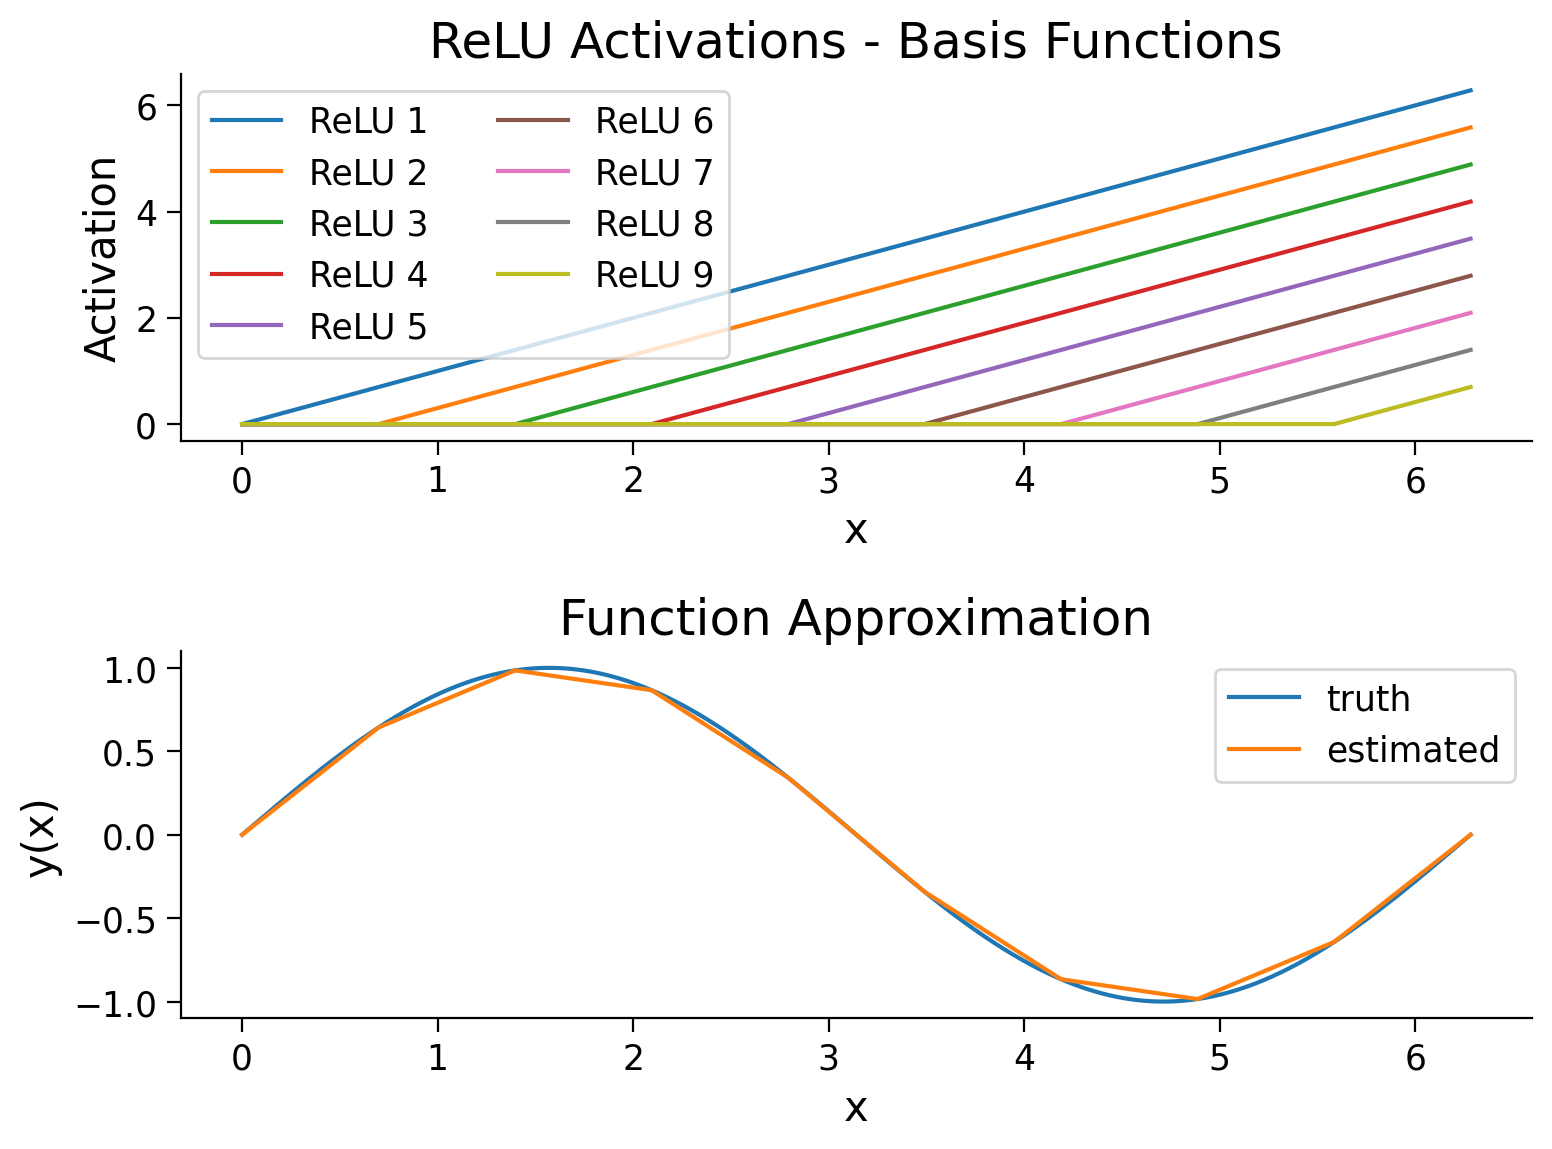

In [22]:
def approximate_function(x_train, y_train):
  """
  Funzione per calcolare e combinare attivazioni ReLU

  Args:
    x_train: torch.tensor
      Dati di training (punti x)
    y_train: torch.tensor
      Valori veri della funzione corrispondenti a x_train

  Returns:
    relu_acts: torch.tensor
      Attivazioni ReLU calcolate per ogni punto lungo l'asse x
    y_hat: torch.tensor
      Stima dei valori della funzione (somma pesata delle attivazioni ReLU)
    x: torch.tensor
      Punti dell'asse x su cui valutiamo l'approssimazione
  """

  # Numero di ReLU = numero punti training - 1
  # Servono per modellare gli intervalli tra i punti
  # Calcola quante ReLU servono. Se hai 10 punti, avrai 9 intervalli, quindi 9 ReLU (una per ogni intervallo).
  n_relus = x_train.shape[0] - 1

  # Crea una griglia fitta di 1000 punti tra il minimo e il massimo dei dati. Servirà per disegnare la funzione nell'intervallo approssimata in modo continuo.
  x = torch.linspace(torch.min(x_train), torch.max(x_train), 1000)

  ## CALCOLO ATTIVAZIONI RELU

  # Crea un array di bias. Ogni bias è il negativo di un punto di training. Questo fa sì che la ReLU si attivi quando x supera quel punto.
  b = -x_train

  # Matrice per memorizzare le attivazioni di ogni ReLU su tutti i punti x
  # Dimensioni: (numero ReLU, 1000 punti)
  relu_acts = torch.zeros((n_relus, x.shape[0]))

  # Calcola l'attivazione di ogni ReLU per tutti i punti x
  # Per ogni ReLU (dalla 0 alla 9), calcola la sua attivazione su tutti i 1000 punti x. Il risultato è una matrice 9×1000.
  for i_relu in range(n_relus):
    # ReLU(x + b[i_relu]) = max(0, x + b[i_relu])
    # b[i_relu] determina il punto in cui questa ReLU si attiva
    relu_acts[i_relu, :] = torch.relu(x + b[i_relu])

  ## COMBINAZIONE ATTIVAZIONI RELU

  # Vettore per i pesi della combinazione lineare delle ReLU
  combination_weights = torch.zeros((n_relus, ))

  # Calcola i pesi in base alle pendenze tra i punti di training
  # Idea: ogni ReLU contribuisce con una pendenza pari alla variazione di pendenza
  prev_slope = 0  # pendenza precedente (inizia da 0)
  for i in range(n_relus):
    # Calcola la pendenza desiderata in ogni intervallo perche ricordiamoci che l obiettivo è sempre fare una funzione che simuli il piu possibile il seno
    delta_x = x_train[i+1] - x_train[i]           # differenza x
    slope = (y_train[i+1] - y_train[i]) / delta_x # pendenza = Δy/Δx

    # Il peso della ReLU è la variazione di pendenza
    # Se la pendenza aumenta, peso positivo; se diminuisce, peso negativo
    combination_weights[i] = slope - prev_slope # -> Determina quanto deve contribuire ogni nuovo cuneo per ottenere la pendenza desiderata.
    # La pendenza in un punto è la somma di tutti i cunei attivi fino a quel punto. Se all'inizio (prima del primo punto) la pendenza è 0, e nel
    # primo intervallo vogliamo pendenza 0.92, allora il primo cuneo deve avere peso 0.92.
    # Nel secondo intervallo, vogliamo pendenza 0.49. Ma abbiamo già un cuneo con peso 0.92 che dovrà essere aggiornato
    prev_slope = slope  # aggiorna pendenza per prossimo intervallo contribuisce. Per ottenere 0.49, dobbiamo aggiungere un cuneo con peso negativo

  # Calcola l'output finale: somma pesata di tutte le attivazioni ReLU
  # Prodotto scalare tra pesi (n_relus) e attivazioni (n_relus, 1000)
  # Risultato: vettore di 1000 punti = funzione approssimata
  y_hat = combination_weights @ relu_acts

  return y_hat, relu_acts, x


# Genera dati di training dalla funzione seno
N_train = 10                           # numero punti training
x_train = torch.linspace(0, 2*np.pi, N_train).view(-1, 1)  # 10 punti tra 0 e 2π
y_train = torch.sin(x_train)           # calcola sin(x) per ogni punto

# Esegue l'approssimazione e visualizza il risultato
y_hat, relu_acts, x = approximate_function(x_train, y_train)
plot_function_approximation(x, relu_acts, y_hat)

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content-dl/tree/main/tutorials/W1D3_MultiLayerPerceptrons/solutions/W1D3_Tutorial1_Solution_d38a6c69.py)

*Example output:*

<img alt='Solution hint' align='left' width=777.0 height=578.0 src=https://raw.githubusercontent.com/NeuromatchAcademy/course-content-dl/main/tutorials/W1D3_MultiLayerPerceptrons/static/W1D3_Tutorial1_Solution_d38a6c69_0.png>



As you see in the top panel, we obtain 10 shifted ReLUs with the same slope. These are the basis functions that MLP uses to span the functional space, i.e., MLP finds a linear combination of these ReLUs.

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Function_approximation_with_ReLU_Exercise")

---
# Section 2: MLPs in PyTorch

*Time estimate: ~1hr and 20 mins*

In [ ]:
# @title Video 2: Building MLPs in PyTorch
from ipywidgets import widgets
from IPython.display import YouTubeVideo
from IPython.display import IFrame
from IPython.display import display


class PlayVideo(IFrame):
  def __init__(self, id, source, page=1, width=400, height=300, **kwargs):
    self.id = id
    if source == 'Bilibili':
      src = f'https://player.bilibili.com/player.html?bvid={id}&page={page}'
    elif source == 'Osf':
      src = f'https://mfr.ca-1.osf.io/render?url=https://osf.io/download/{id}/?direct%26mode=render'
    super(PlayVideo, self).__init__(src, width, height, **kwargs)


def display_videos(video_ids, W=400, H=300, fs=1):
  tab_contents = []
  for i, video_id in enumerate(video_ids):
    out = widgets.Output()
    with out:
      if video_ids[i][0] == 'Youtube':
        video = YouTubeVideo(id=video_ids[i][1], width=W,
                             height=H, fs=fs, rel=0)
        print(f'Video available at https://youtube.com/watch?v={video.id}')
      else:
        video = PlayVideo(id=video_ids[i][1], source=video_ids[i][0], width=W,
                          height=H, fs=fs, autoplay=False)
        if video_ids[i][0] == 'Bilibili':
          print(f'Video available at https://www.bilibili.com/video/{video.id}')
        elif video_ids[i][0] == 'Osf':
          print(f'Video available at https://osf.io/{video.id}')
      display(video)
    tab_contents.append(out)
  return tab_contents


video_ids = [('Youtube', 'XtwLnaYJ7uc'), ('Bilibili', 'BV1zh411z7LY')]
tab_contents = display_videos(video_ids, W=854, H=480)
tabs = widgets.Tab()
tabs.children = tab_contents
for i in range(len(tab_contents)):
  tabs.set_title(i, video_ids[i][0])
display(tabs)

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Building_MLPs_in_PyTorch_Video")

In the previous segment, we implemented a function to approximate any smooth function using MLPs. We saw that using Lipschitz continuity; We can prove that our approximation is mathematically correct. MLPs are fascinating, but before we get into the details on designing them, let's familiarize ourselves with some basic terminology of MLPs - layer, neuron, depth, width, weight, bias, and activation function. Armed with these ideas, we can now design an MLP given its input, hidden layers, and output size.

## Coding Exercise 2: Implement a general-purpose MLP in Pytorch
The objective is to design an MLP with these properties:
* Works with any input (1D, 2D, etc.)
* Construct any number of given hidden layers using `nn.Sequential()` and `add_module()` function
* Use the same given activation function (i.e., [Leaky ReLU](https://pytorch.org/docs/stable/generated/torch.nn.LeakyReLU.html)) in all hidden layers

**Leaky ReLU** is described by the following mathematical formula:

\begin{align}
\text{LeakyReLU}(x) &= \text{max}(0,x) + \text{negative_slope} \cdot \text{min}(0, x) \\
&=
\left\{
  \begin{array}{ll}
  x & ,\; \text{if} \; x \ge 0 \\
  \text{negative_slope} \cdot x & ,\;  \text{otherwise}
  \end{array}
\right.
\end{align}

In [24]:
# ============================================================
# CLASSE MLP GENERALE
# ============================================================

class Net(nn.Module):
  """
  Classe per creare un Multi-Layer Perceptron (MLP) generico.
  Può creare reti con qualsiasi numero di layer nascosti,
  qualsiasi attivazione, e qualsiasi dimensione di input/output.
  """

  def __init__(self, actv, input_feature_num, hidden_unit_nums, output_feature_num):
    """
    Costruttore della classe - inizializza i parametri della rete.

    Args:
      actv: stringa
        Nome della funzione di attivazione (es. 'ReLU()', 'LeakyReLU(0.1)')
      input_feature_num: intero
        Numero di feature in input (es. 2 per coordinate, 784 per MNIST)
      hidden_unit_nums: lista
        Lista di interi, uno per ogni layer nascosto.
        Esempio: [100, 50, 25] = 3 layer con 100, 50, 25 neuroni
      output_feature_num: intero
        Numero di neuroni in output (es. 10 per classificazione 10 classi)

    Returns:
      Niente
    """
    # Chiama il costruttore della classe madre nn.Module
    # Necessario per il corretto funzionamento di PyTorch
    super(Net, self).__init__()

    # Salva il numero di feature input come attributo della classe
    # Servirà nel forward per fare il reshape dell'input
    self.input_feature_num = input_feature_num

    # Crea un contenitore Sequential per impilare i layer in ordine
    # Tutti i layer aggiunti qui verranno eseguiti sequenzialmente
    self.mlp = nn.Sequential()

    # Variabile temporanea per tracciare la dimensione di input del prossimo layer
    # Inizia con la dimensione dell'input della rete
    in_num = input_feature_num

    # CICLO PER CREARE I LAYER NASCOSTI
    # Itera su ogni elemento della lista hidden_unit_nums
    for i in range(len(hidden_unit_nums)):

      # out_num = numero di neuroni per questo layer nascosto
      out_num = hidden_unit_nums[i]

      # Crea un layer lineare (fully connected)
      # Riceve in_num input, produce out_num output
      layer = nn.Linear(in_num, out_num)

      # AGGIORNA in_num PER IL PROSSIMO LAYER
      # L'output di questo layer diventerà l'input del prossimo
      in_num = out_num

      # Aggiunge il layer lineare al contenitore Sequential
      # Il nome 'Linear_%d' permette di identificare il layer
      self.mlp.add_module('Linear_%d' % i, layer)

      # CREA IL LAYER DI ATTIVAZIONE
      # eval() è una funzione Python che esegue una stringa come codice
      # Se actv = 'LeakyReLU(0.1)', allora 'nn.%s' % actv diventa 'nn.LeakyReLU(0.1)'
      # eval('nn.LeakyReLU(0.1)') crea un oggetto nn.LeakyReLU(0.1)
      actv_layer = eval('nn.%s' % actv)

      # Aggiunge l'attivazione al contenitore Sequential
      # Nota: l'attivazione viene creata SEPARATAMENTE per ogni layer
      # perché alcune attivazioni (es. PReLU) hanno parametri apprendibili
      self.mlp.add_module('Activation_%d' % i, actv_layer)

    # CREAZIONE DEL LAYER DI OUTPUT
    # Dopo il ciclo, in_num contiene l'output dell'ULTIMO layer nascosto
    # Crea un layer lineare che va da in_num a output_feature_num
    out_layer = nn.Linear(in_num, output_feature_num)

    # Aggiunge il layer di output al contenitore Sequential
    # IMPORTANTE: nessuna attivazione sull'output (vogliamo logits)
    self.mlp.add_module('Output_Linear', out_layer)


  def forward(self, x):
    """
    Simula il passaggio in avanti (forward pass) della rete.

    Args:
      x: torch.Tensor
        Dati di input (può essere di qualsiasi forma)

    Returns:
      logits: torch.Tensor
        Output della rete (logits, cioè valori grezzi senza attivazione finale)
    """
    # RIMODELLA L'INPUT
    # x.view(-1, self.input_feature_num) appiattisce l'input in forma:
    # (batch_size, input_feature_num)
    # -1 significa "calcola automaticamente questa dimensione"
    # Utile per input multidimensionali come immagini (C, H, W)
    x = x.view(-1, self.input_feature_num)

    # PASSAGGIO ATTRAVERSO LA RETE
    # self.mlp(x) esegue TUTTI i layer in ordine:
    # Linear_0 → Activation_0 → Linear_1 → Activation_1 → ... → Output_Linear
    logits = self.mlp(x)

    # Restituisce l'output (logits)
    return logits


# ============================================================
# TEST DELLA CLASSE
# ============================================================

# CREAZIONE DATI DI TEST
# Crea un tensore di 100 campioni, ognuno con 2 feature
# Tutti i valori sono zero (input fittizio per test)
input = torch.zeros((100, 2))

# CREAZIONE DELLA RETE
# Crea un'istanza della classe Net con:
# - Attivazione: LeakyReLU con parametro negative_slope = 0.1
# - Input: 2 feature
# - Layer nascosti: 3 layer con 100, 10, 5 neuroni
# - Output: 1 neurone (es. regressione o classificazione binaria)
# .to(DEVICE) sposta la rete su GPU se disponibile
net = Net(
    actv='LeakyReLU(0.1)',
    input_feature_num=2,
    hidden_unit_nums=[100, 10, 5],
    output_feature_num=1
).to(DEVICE)

# FORWARD PASS
# Passa l'input attraverso la rete
# L'input viene spostato sullo stesso device della rete
y = net(input.to(DEVICE))

# VERIFICA DELLE DIMENSIONI
# Stampa la forma dell'output e dell'input per verificare che tutto funzioni
print(f'The output shape is {y.shape} for an input of shape {input.shape}')
# Output atteso: "The output shape is torch.Size([100, 1]) for an input of shape torch.Size([100, 2])"

The output shape is torch.Size([100, 1]) for an input of shape torch.Size([100, 2])


[*Click for solution*](https://github.com/NeuromatchAcademy/course-content-dl/tree/main/tutorials/W1D3_MultiLayerPerceptrons/solutions/W1D3_Tutorial1_Solution_a1ac91af.py)



```
The output shape is torch.Size([100, 1]) for an input of shape torch.Size([100, 2])
```

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Implement_a_general_purpose_MLP_in_PyTorch_Exercise")

## Section 2.1: Classification with MLPs

In [ ]:
# @title Video 3: Cross Entropy
from ipywidgets import widgets
from IPython.display import YouTubeVideo
from IPython.display import IFrame
from IPython.display import display


class PlayVideo(IFrame):
  def __init__(self, id, source, page=1, width=400, height=300, **kwargs):
    self.id = id
    if source == 'Bilibili':
      src = f'https://player.bilibili.com/player.html?bvid={id}&page={page}'
    elif source == 'Osf':
      src = f'https://mfr.ca-1.osf.io/render?url=https://osf.io/download/{id}/?direct%26mode=render'
    super(PlayVideo, self).__init__(src, width, height, **kwargs)


def display_videos(video_ids, W=400, H=300, fs=1):
  tab_contents = []
  for i, video_id in enumerate(video_ids):
    out = widgets.Output()
    with out:
      if video_ids[i][0] == 'Youtube':
        video = YouTubeVideo(id=video_ids[i][1], width=W,
                             height=H, fs=fs, rel=0)
        print(f'Video available at https://youtube.com/watch?v={video.id}')
      else:
        video = PlayVideo(id=video_ids[i][1], source=video_ids[i][0], width=W,
                          height=H, fs=fs, autoplay=False)
        if video_ids[i][0] == 'Bilibili':
          print(f'Video available at https://www.bilibili.com/video/{video.id}')
        elif video_ids[i][0] == 'Osf':
          print(f'Video available at https://osf.io/{video.id}')
      display(video)
    tab_contents.append(out)
  return tab_contents


video_ids = [('Youtube', 'N8pVCbTlves'), ('Bilibili', 'BV1Ag41177mB')]
tab_contents = display_videos(video_ids, W=854, H=480)
tabs = widgets.Tab()
tabs.children = tab_contents
for i in range(len(tab_contents)):
  tabs.set_title(i, video_ids[i][0])
display(tabs)

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Cross_Entropy_Video")

The main loss function we could use out of the box for multi-class classification for `N` samples and `C` number of classes is:

* **CrossEntropyLoss**:
This criterion expects a batch of predictions `x` with shape `(N, C)` and class index in the range $[0, C-1]$ as the target (label) for each `N` samples, hence a batch of `labels` with shape `(N, )`. There are other optional parameters like class weights and class ignores. Feel free to check the PyTorch documentation [here](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) for more detail. Additionally, [here](https://sparrow.dev/cross-entropy-loss-in-pytorch/) you can learn where is appropriate to use the CrossEntropyLoss.

To get CrossEntropyLoss of a sample $i$, we could first calculate $-\log(\text{softmax}(x))$ and then take the element corresponding to $\text {labels}_i$ as the loss. However, due to numerical stability, we implement this more stable equivalent form,

\begin{equation}
\operatorname{loss}(x_i, \text {labels}_i)=-\log \left(\frac{\exp (x[\text {labels}_i])}{\sum_{j} \exp (x[j])}\right)=-x_i[\text {labels}_i]+\log \left(\sum_{j=1}^C \exp (x_i[j])\right)
\end{equation}

### Coding Exercise 2.1: Implement Batch Cross Entropy Loss

To recap, since we will be doing batch learning, we'd like a loss function that given:
* A batch of predictions `x` with shape `(N, C)`
* A batch of `labels` with shape `(N, )` that ranges from `0` to `C-1`

Returns the average loss $L$ calculated according to:

\begin{align}
\text{loss}(x_i, \text {labels}_i) &= -x_i[\text {labels}_i]+\log \left(\sum_{j=1}^C \exp (x_i[j])\right) \\
L &= \frac{1}{N} \sum_{i=1}^{N}{\text{loss}(x_i, \text {labels}_i)}
\end{align}

Steps:

1.   Use indexing operation to get predictions of class corresponding to the labels (i.e., $x_i[\text { labels }_i]$)
2.   Compute $loss(x_i, \text { labels }_i)$ vector (`losses`) using `torch.log()` and `torch.exp()` without Loops!
3. Return the average of the loss vector

In [25]:
def cross_entropy_loss(x, labels):
  """
  Funzione helper per calcolare la cross entropy loss

  Args:
    x: torch.tensor
      Predizioni del modello (logits) con shape (N, C)
      dove N = numero campioni, C = numero classi
    labels: torch.tensor
      Etichette vere con shape (N,), valori interi da 0 a C-1

  Returns:
    avg_loss: float
      Media delle loss sul batch
  """

  # Crea un tensore di zeri della stessa lunghezza di labels
  # Servirà a memorizzare il logit(valori grezzi in uscita dall'ultimo layer di una rete,Non hanno un significato probabilistico)
  # della classe corretta per ogni campione
  x_of_labels = torch.zeros(len(labels))

  # 1. Estrae la predizione per la classe corretta di ogni campione
  # Itera su ogni campione i e sulla sua etichetta label
  for i, label in enumerate(labels):
    # x[i, label] prende il logit corrispondente alla classe vera per il campione i
    # Esempio: se x[i] = [2.1, 5.3, 1.2] e label = 1, prende 5.3
    x_of_labels[i] = x[i, label]

  # 2. Calcola il vettore delle loss per ogni campione
  # Formula: loss(i) = -x[i, label] + log(∑ exp(x[i, j]))
  # -x_of_labels: contributo negativo del logit corretto
  # torch.log(...): logaritmo naturale
  # torch.sum(torch.exp(x), dim=1): somma degli esponenziali per ogni campione
  losses = -x_of_labels + torch.log(torch.sum(torch.exp(x), dim=1))

  # 3. Calcola la media delle loss sul batch
  # .mean() restituisce la media di tutti i valori nel tensore
  avg_loss = losses.mean()

  return avg_loss



labels = torch.tensor([0, 1])
x = torch.tensor([[10.0, 1.0, -1.0, -20.0],  # Correctly classified
                  [10.0, 10.0, 2.0, -10.0]])  # Not correctly classified
CE = nn.CrossEntropyLoss()
pytorch_loss = CE(x, labels).item()
## Uncomment below to test your function
our_loss = cross_entropy_loss(x, labels).item()
print(f'Our CE loss: {our_loss:0.8f}, Pytorch CE loss: {pytorch_loss:0.8f}')
print(f'Difference: {np.abs(our_loss - pytorch_loss):0.8f}')

Our CE loss: 0.34672737, Pytorch CE loss: 0.34672749
Difference: 0.00000012


[*Click for solution*](https://github.com/NeuromatchAcademy/course-content-dl/tree/main/tutorials/W1D3_MultiLayerPerceptrons/solutions/W1D3_Tutorial1_Solution_4049041f.py)



```
Our CE loss: 0.34672737, Pytorch CE loss: 0.34672749
Difference: 0.00000012
```

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Implement_Batch_Cross_Entropy_Loss_Exercise")

## Section 2.2: Spiral Classification Dataset
Before we could start optimizing these loss functions, we need a dataset!

Let's turn this fancy-looking equation into a classification dataset

\begin{equation}
\begin{array}{c}
X_{k}(t)=t\left(\begin{array}{c}
\sin \left[\frac{2 \pi}{K}\left(2 t+k-1\right)\right]+\mathcal{N}\left(0, \sigma\right) \\
\cos \left[\frac{2 \pi}{K}\left(2 t+k-1\right)\right]+\mathcal{N}\left(0, \sigma\right)
\end{array}\right)
\end{array}, \quad 0 \leq t \leq 1, \quad k=1, \ldots, K
\end{equation}

Random seed 2021 has been set.


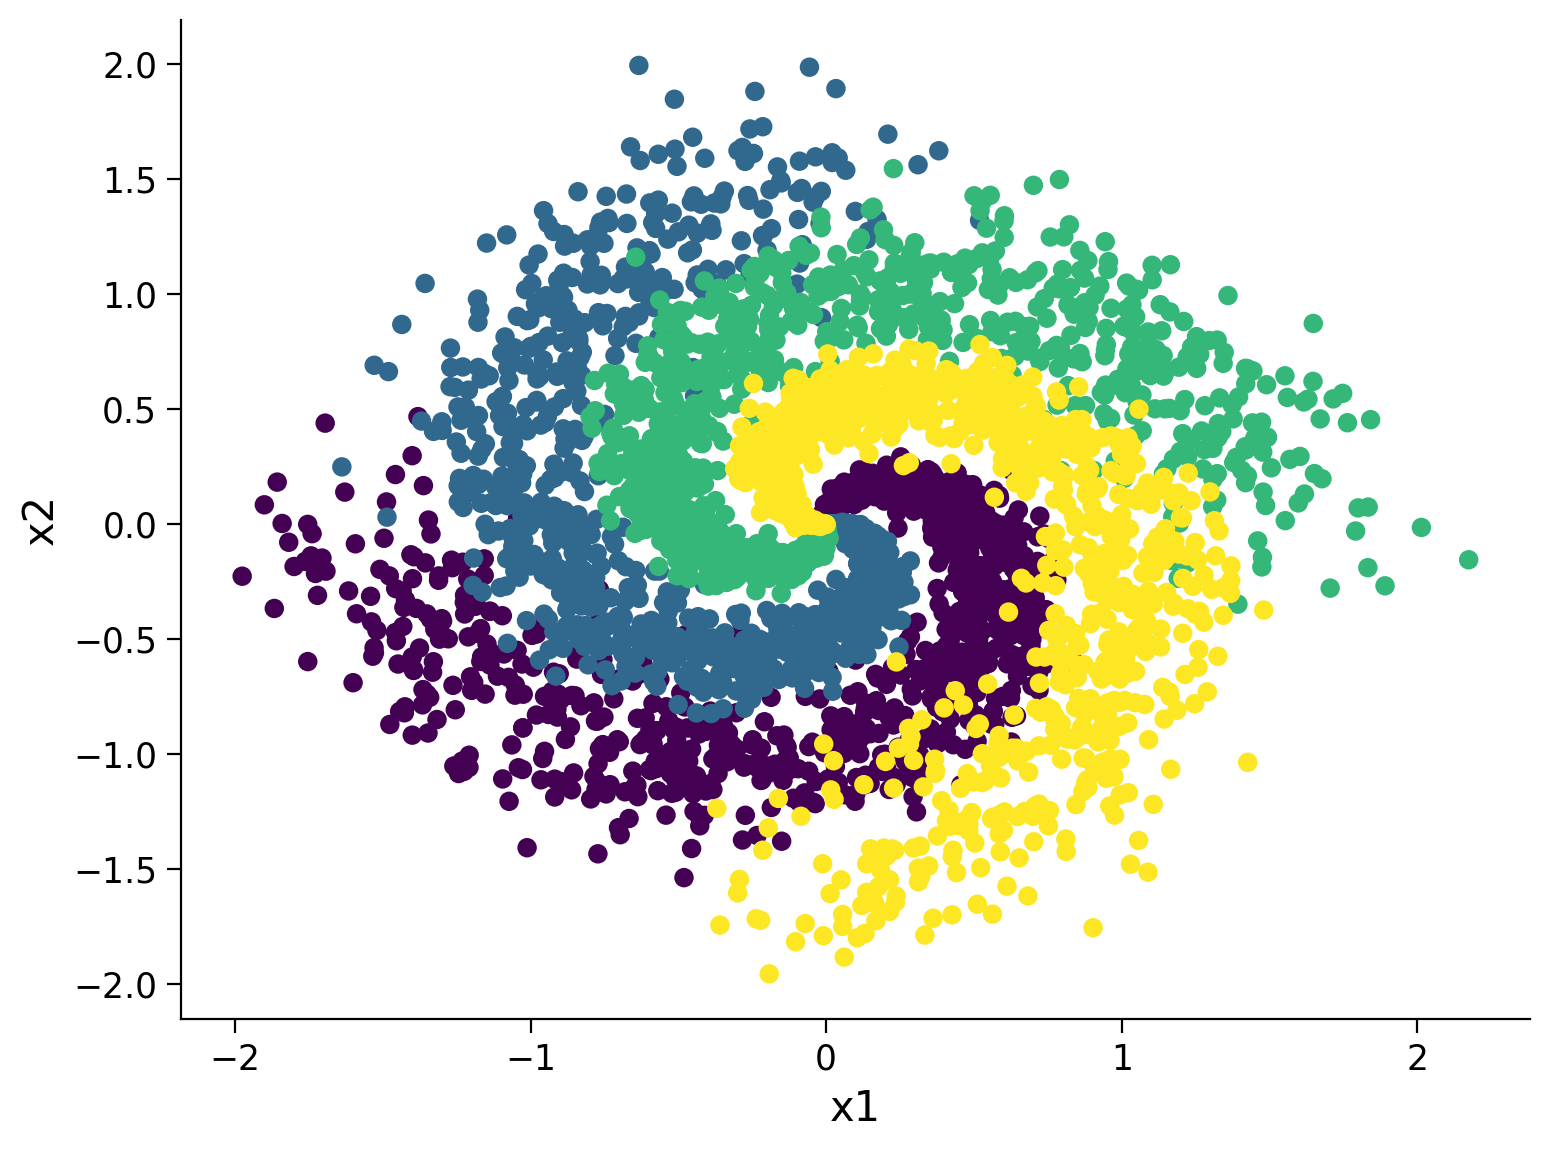

In [59]:
def create_spiral_dataset(K, sigma, N):
  """
  Funzione per simulare un dataset a spirale con K classi

  Args:
    K: int
      Numero di classi (ogni classe è un braccio della spirale)
    sigma: float
      Deviazione standard del rumore gaussiano (più alto = più dispersione)
    N: int
      Numero di punti da generare per OGNI classe

  Returns:
    X: torch.tensor
      Dati a spirale con shape (K*N, 2) - coordinate x e y
    y: torch.tensor
      Etichette corrispondenti con shape (K*N,) - valori da 0 a K-1
  """

  # ============================================================
  # INIZIALIZZAZIONE
  # ============================================================

  # t è un vettore di N valori equidistanti tra 0 e 1
  # Determina la distanza dall'origine: t piccolo = vicino, t grande = lontano
  # t = [0.00, 0.25, 0.50, 0.75, 1.00]
  # Per t=0.75:Vengono generati K(le classi) punti (uno per ogni classe), tutti a distanza 0.75 dal centro.
  t = torch.linspace(0, 1.5, N)

  # X conterrà TUTTI i punti (K*N righe, 2 colonne)
  # Le colonne sono le coordinate x e y
  X = torch.zeros(K*N, 2)

  # y conterrà le etichette per TUTTI i punti
  y = torch.zeros(K*N)

  # ============================================================
  # GENERAZIONE DATI PER OGNI CLASSE
  # ============================================================

  # Itera su ogni classe da 0 a K-1
  for k in range(K):

    # INDICI per i punti della classe k:
    # Partono da k*N e finiscono a (k+1)*N (escluso)
    # Esempio con K=4, N=1000:
    # - Classe 0: righe 0-999
    # - Classe 1: righe 1000-1999
    # - Classe 2: righe 2000-2999
    # - Classe 3: righe 3000-3999

    # COORDINATA X per la classe k
    # Formula: x = t * [sin(2π/K * (2t + k)) + rumore]
    # - 2π/K definisce l'angolo tra i bracci della spirale
    # - (2t + k) è la fase che dipende da t e dalla classe
    # - sigma*torch.randn(N) aggiunge rumore gaussiano (media 0, dev std sigma)
    X[k*N:(k+1)*N, 0] = t * (torch.sin(2*np.pi/K * (2*t + k)) + sigma * torch.randn(N))

    # COORDINATA Y per la classe k
    # Formula: y = t * [cos(2π/K * (2t + k)) + rumore]
    X[k*N:(k+1)*N, 1] = t * (torch.cos(2*np.pi/K * (2*t + k)) + sigma * torch.randn(N))

    # ETICHETTE per la classe k
    # Assegna il valore k a tutti i punti di questa classe
    y[k*N:(k+1)*N] = k

  # Restituisce i dati e le etichette
  return X, y


# ============================================================
# PARAMETRI E GENERAZIONE DATASET
# ============================================================

K = 4          # Numero di classi: 4 bracci della spirale
sigma = 0.16   # Deviazione standard del rumore (valore moderato)
N = 1000       # Punti per classe: 1000 → totale 4000 punti

# Imposta il seed per riproducibilità
set_seed(seed=SEED)

# Genera il dataset
X, y = create_spiral_dataset(K, sigma, N)

# ============================================================
# VISUALIZZAZIONE
# ============================================================

# Crea un grafico a dispersione
# X[:, 0] = coordinate x, X[:, 1] = coordinate y
# c = y assegna un colore diverso a ogni classe
plt.scatter(X[:, 0], X[:, 1], c = y)

# Etichette degli assi
plt.xlabel('x1')
plt.ylabel('x2')

# Mostra il grafico
plt.show()

## Section 2.3: Training and Evaluation

In [ ]:
# @title Video 4: Training and Evaluating an MLP
from ipywidgets import widgets
from IPython.display import YouTubeVideo
from IPython.display import IFrame
from IPython.display import display


class PlayVideo(IFrame):
  def __init__(self, id, source, page=1, width=400, height=300, **kwargs):
    self.id = id
    if source == 'Bilibili':
      src = f'https://player.bilibili.com/player.html?bvid={id}&page={page}'
    elif source == 'Osf':
      src = f'https://mfr.ca-1.osf.io/render?url=https://osf.io/download/{id}/?direct%26mode=render'
    super(PlayVideo, self).__init__(src, width, height, **kwargs)


def display_videos(video_ids, W=400, H=300, fs=1):
  tab_contents = []
  for i, video_id in enumerate(video_ids):
    out = widgets.Output()
    with out:
      if video_ids[i][0] == 'Youtube':
        video = YouTubeVideo(id=video_ids[i][1], width=W,
                             height=H, fs=fs, rel=0)
        print(f'Video available at https://youtube.com/watch?v={video.id}')
      else:
        video = PlayVideo(id=video_ids[i][1], source=video_ids[i][0], width=W,
                          height=H, fs=fs, autoplay=False)
        if video_ids[i][0] == 'Bilibili':
          print(f'Video available at https://www.bilibili.com/video/{video.id}')
        elif video_ids[i][0] == 'Osf':
          print(f'Video available at https://osf.io/{video.id}')
      display(video)
    tab_contents.append(out)
  return tab_contents


video_ids = [('Youtube', 'DfXZhRfBEqQ'), ('Bilibili', 'BV1QV411p7mF')]
tab_contents = display_videos(video_ids, W=854, H=480)
tabs = widgets.Tab()
tabs.children = tab_contents
for i in range(len(tab_contents)):
  tabs.set_title(i, video_ids[i][0])
display(tabs)

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Training_and_Evaluating_an_MLP_Video")

### Coding Exercise 2.3: Implement it for a classfication task
Now that we have the spiral dataset and a loss function, it's your turn to implement a simple train/test split for training and validation.

Steps to follow:
  * Dataset shuffle
  * Train/Test split (20% for test)
  * Dataloader definition
  * Training and Evaluation

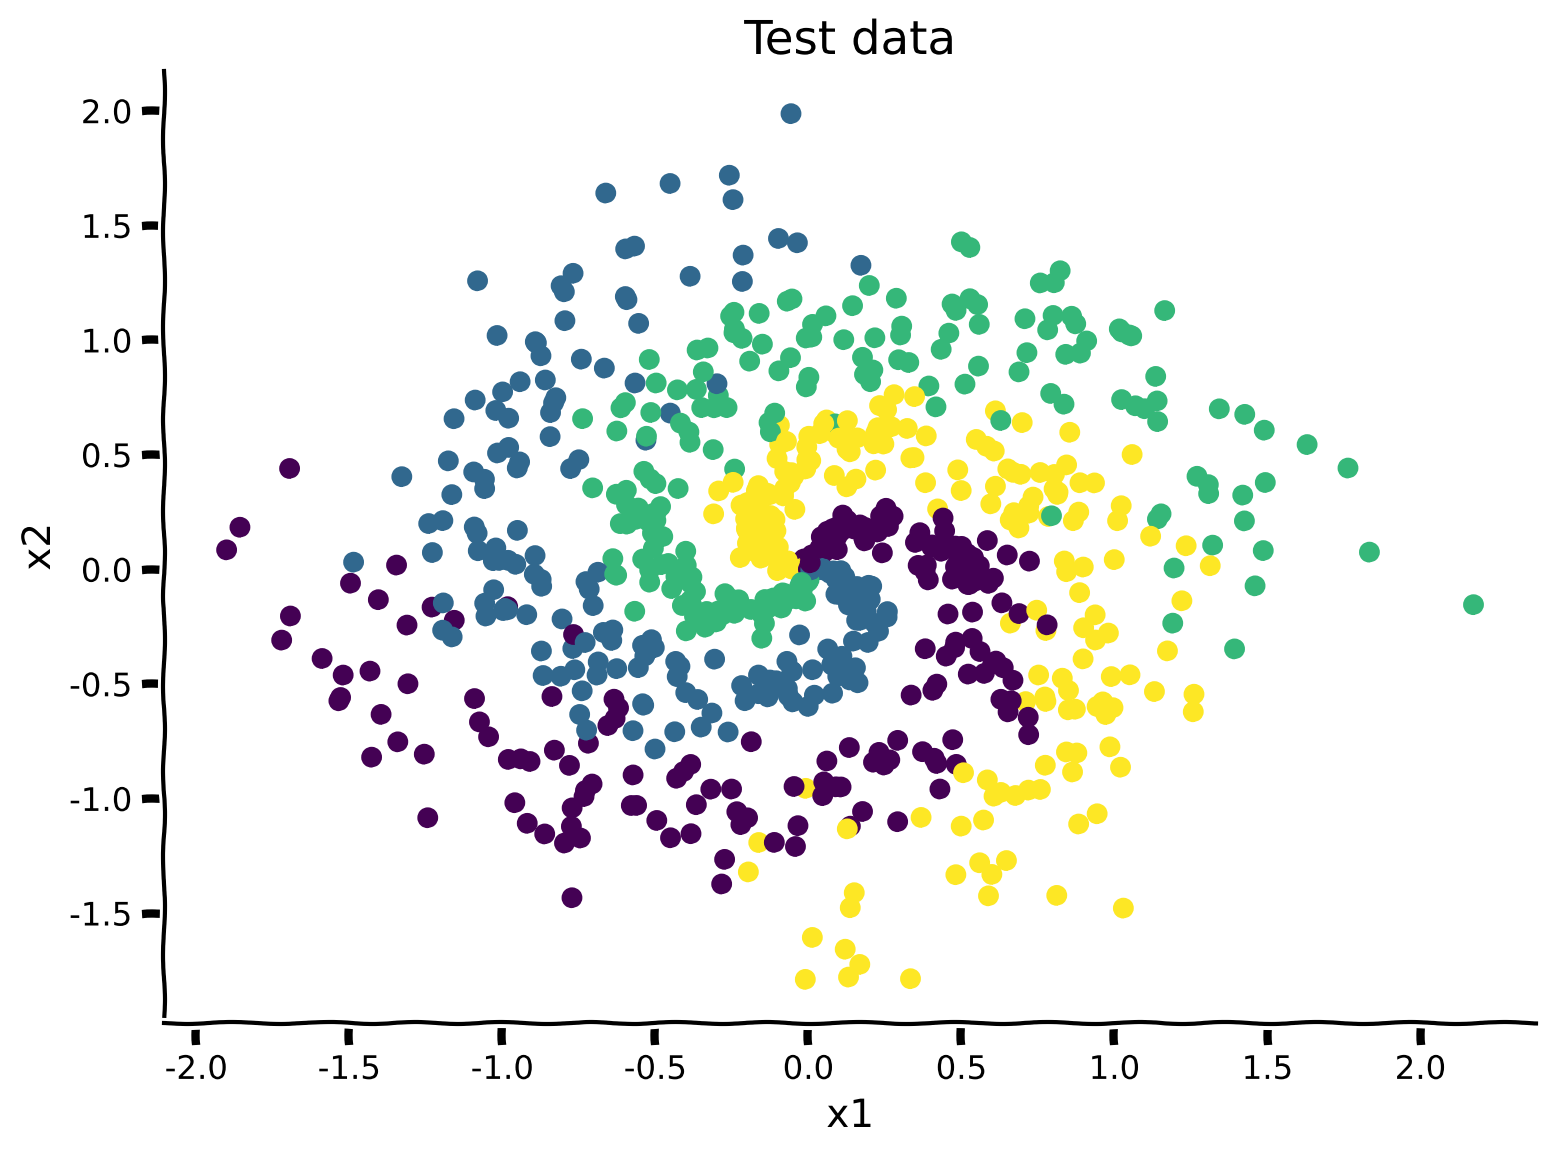

In [27]:
def shuffle_and_split_data(X, y, seed):
  """
  Funzione helper per mescolare e dividere i dati in training e test

  Args:
    X: torch.tensor
      Dati di input (features) con shape (N, D) dove:
      N = numero totale di campioni
      D = numero di feature (es. 2 per coordinate x,y)
    y: torch.tensor
      Etichette corrispondenti con shape (N,)
      Valori interi da 0 a K-1 (K = numero classi)
    seed: int
      Seed per garantire che la mescolatura sia RIPRODUCIBILE
      (stesso seed = stesso ordine casuale ogni volta)

  Returns:
    X_test: torch.tensor
      Dati di test (20% di X) - NON usati durante l'addestramento
    y_test: torch.tensor
      Etichette corrispondenti ai dati di test
    X_train: torch.tensor
      Dati di training (80% di X) - usati per addestrare il modello
    y_train: torch.tensor
      Etichette corrispondenti ai dati di training
  """

  # ============================================================
  # 1. IMPOSTA IL SEED PER RIPRODUCIBILITÀ
  # ============================================================
  # Fissa il generatore casuale di PyTorch
  # Stesso seed = stessa sequenza di numeri casuali
  torch.manual_seed(seed)

  # ============================================================
  # 2. DETERMINA IL NUMERO TOTALE DI CAMPIONI
  # ============================================================
  # X.shape[0] è il numero di righe (campioni)
  # Esempio: se X ha 4000 righe, N = 4000
  N = X.shape[0]

  # ============================================================
  # 3. MESCOLA I DATI (SHUFFLE)
  # ============================================================
  # torch.randperm(N) genera una permutazione casuale degli indici 0...N-1
  # Esempio: per N=5 potrebbe dare [3, 0, 4, 1, 2]
  shuffled_indices = torch.randperm(N)

  # Riordina X e y usando gli stessi indici casuali
  # Così manteniamo la corrispondenza tra dati ed etichette
  X = X[shuffled_indices]  # X ora è mescolato
  y = y[shuffled_indices]  # y mescolato allo stesso modo

  # ============================================================
  # 4. SPLIT TRAIN/TEST (80/20)
  # ============================================================
  # Calcola quanti campioni mettere nel test set (20% del totale)
  # int() assicura che sia un numero intero
  # Esempio: N=4000 → 4000 * 0.2 = 800
  test_size = int(N * (20/100))

  # TEST SET: primi `test_size` campioni (dopo lo shuffle)
  # Indici da 0 a test_size-1
  X_test = X[:test_size]
  y_test = y[:test_size]

  # TRAINING SET: campioni rimanenti
  # Indici da test_size fino alla fine
  X_train = X[test_size:]
  y_train = y[test_size:]

  # Restituisce i quattro tensori
  return X_test, y_test, X_train, y_train


# ============================================================
# TEST DELLA FUNZIONE
# ============================================================

# Esegue la funzione con i dati generati precedentemente
# X e y sono il dataset a spirale creato prima
# seed=SEED garantisce che lo shuffle sia sempre lo stesso
X_test, y_test, X_train, y_train = shuffle_and_split_data(X, y, seed=SEED)

# ============================================================
# VISUALIZZAZIONE DEL TEST SET
# ============================================================

# with plt.xkcd() attiva lo stile fumettistico di matplotlib
with plt.xkcd():
  # Crea una nuova figura
  plt.figure()

  # Grafico a dispersione dei dati di test
  # X_test[:, 0] = coordinate x, X_test[:, 1] = coordinate y
  # c = y_test assegna colori diversi in base alla classe
  plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test)

  # Etichette degli assi
  plt.xlabel('x1')
  plt.ylabel('x2')

  # Titolo del grafico
  plt.title('Test data')

  # Mostra il grafico
  plt.show()

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content-dl/tree/main/tutorials/W1D3_MultiLayerPerceptrons/solutions/W1D3_Tutorial1_Solution_61854a92.py)

*Example output:*

<img alt='Solution hint' align='left' width=777.0 height=578.0 src=https://raw.githubusercontent.com/NeuromatchAcademy/course-content-dl/main/tutorials/W1D3_MultiLayerPerceptrons/static/W1D3_Tutorial1_Solution_61854a92_0.png>



In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Implement_it_for_a_classification_task_Exercise")

And we need to make a Pytorch data loader out of it. Data loading in PyTorch can be separated in 2 parts:
* Data must be wrapped on a Dataset parent class where the methods __getitem__ and __len__ must be overrided. Note that, at this point, the data is not loaded on memory. PyTorch will only load what is needed to the memory. Here `TensorDataset` does this for us directly.
* Use a Dataloader that will actually read the data in batches and put into memory. Also, the option of `num_workers > 0` allows multithreading, which prepares multiple batches in the queue to speed things up.

In [28]:
# ============================================================
# GENERATORE PER NUMERI CASUALI (RIPRODUCIBILITÀ)
# ============================================================

# Crea un generatore di numeri casuali separato
# Serve per controllare la casualità nello shuffle dei dati
g_seed = torch.Generator()

# Imposta il seme del generatore con SEED (es. 2021)
# Così ogni volta che esegui il codice, lo shuffle sarà identico
g_seed.manual_seed(SEED)


# ============================================================
# PARAMETRI COMUNI
# ============================================================

# Ogni batch conterrà 128 campioni
# Compromesso tra velocità (batch grandi) e memoria (batch piccoli)
batch_size = 128


# ============================================================
# DATASET E DATALOADER PER IL TEST SET
# ============================================================

# Avvolge i tensori X_test e y_test in un oggetto Dataset
# NOTA: i dati NON sono ancora in memoria! Solo preparati.
test_data = TensorDataset(X_test, y_test)

# Crea il DataLoader per il test set
test_loader = DataLoader(
    test_data,                # Il dataset da caricare
    batch_size=batch_size,    # 128 campioni per batch
    shuffle=False,             # NON mescolare i dati di test (ordine non importante)
    num_workers=2,             # 2 processi paralleli per caricare dati più velocemente
    worker_init_fn=seed_worker, # Inizializza i seed in ogni worker (riproducibilità)
    generator=g_seed           # Usa il generatore per operazioni casuali
)


# ============================================================
# DATASET E DATALOADER PER IL TRAINING SET
# ============================================================

# Avvolge i tensori X_train e y_train in un oggetto Dataset
train_data = TensorDataset(X_train, y_train)

# Crea il DataLoader per il training set
train_loader = DataLoader(
    train_data,                # Il dataset da caricare
    batch_size=batch_size,     # 128 campioni per batch
    drop_last=True,             # Scarta l'ultimo batch se ha meno di 128 campioni
                               # Utile per layer come BatchNorm che richiedono batch consistenti
    shuffle=True,               # MESCOLA i dati a ogni epoca (FONDAMENTALE!)
                               # Evita che il modello impari l'ordine dei dati
    num_workers=2,              # 2 processi paralleli
    worker_init_fn=seed_worker, # Inizializza i seed
    generator=g_seed            # Usa lo stesso generatore
)

Let's write a general-purpose training and evaluation code and keep it in our pocket for next tutorial as well. So make sure you review it to see what it does.

Note that `model.train()` tells your model that you are training the model. So layers like dropout, batch norm etc. which behave different on the train and test procedures know what is going on and hence can behave accordingly. And to turn off training mode we set `model.eval()`.

In [31]:
def train_test_classification(net, criterion, optimizer, train_loader,
                              test_loader, num_epochs=1, verbose=True,
                              training_plot=False, device='cpu'):
  """
  Funzione generale per addestrare e valutare un modello di classificazione

  Args:
    net: istanza della classe Net
      Il modello MLP da addestrare
    criterion: torch.nn type
      Funzione di loss (es. CrossEntropyLoss)
    optimizer: torch.optim type
      Ottimizzatore (es. Adam, SGD)
    train_loader: torch.utils.data type
      DataLoader per i dati di training
    test_loader: torch.utils.data type
      DataLoader per i dati di test
    num_epochs: int
      Numero di epoche (default: 1)
    verbose: boolean
      Se True, stampa statistiche e mostra progresso
    training_plot=False
      Se True, mostra il grafico dell'andamento della loss durante training
    device: string
      'cuda' se GPU disponibile, altrimenti 'cpu'

  Returns:
    train_acc, test_acc: float
      Accuratezza percentuale su training set e test set
  """

  # ============================================================
  # FASE 1: ADDESTRAMENTO
  # ============================================================

  # Imposta il modello in modalità TRAINING
  # Attiva dropout, batch normalization si aggiorna sui dati
  net.train()

  # Lista per memorizzare i valori di loss a ogni batch
  # Utile per visualizzare l'andamento dell'addestramento
  training_losses = []

  # tqdm mostra una barra di progresso durante le epoche
  # Itera sul numero di epoche specificato
  for epoch in tqdm(range(num_epochs)):

    # Itera su tutti i batch nel train_loader
    # enumerate(..., 0) parte da indice 0
    for i, data in enumerate(train_loader, 0):

      # ========================================================
      # 1. PREPARAZIONE DEL BATCH
      # ========================================================

      # data è una lista contenente [inputs, labels] dal DataLoader
      inputs, labels = data

      # Sposta i dati sul device appropriato (GPU/CPU)
      # .float() converte a float32 per il modello
      inputs = inputs.to(device).float()

      # .long() converte a interi lunghi (CrossEntropyLoss li richiede così)
      labels = labels.to(device).long()

      # ========================================================
      # 2. RESET DEI GRADIENTI
      # ========================================================

      # Azzera i gradienti accumulati dal batch precedente
      # Fondamentale! Altrimenti i gradienti si sommano tra batch
      optimizer.zero_grad()

      # ========================================================
      # 3. FORWARD PASS
      # ========================================================

      # Passa gli input attraverso la rete
      # outputs sono i LOGITS (shape: batch_size × numero_classi)
      outputs = net(inputs)

      # ========================================================
      # 4. CALCOLO DELLA LOSS
      # ========================================================

      # Confronta le predizioni (outputs) con le etichette vere (labels)
      # criterion è tipicamente CrossEntropyLoss
      loss = criterion(outputs, labels)

      # ========================================================
      # 5. BACKWARD PASS
      # ========================================================

      # Calcola i gradienti per tutti i parametri della rete
      # Partendo dalla loss, percorre il grafo all'indietro
      loss.backward()

      # ========================================================
      # 6. AGGIORNAMENTO DEI PESI
      # ========================================================

      # Applica la discesa del gradiente
      # optimizer.step() aggiorna tutti i parametri usando i gradienti calcolati
      optimizer.step()

      # ========================================================
      # 7. LOGGING (opzionale)
      # ========================================================

      if verbose:
        # loss.item() estrae il valore scalare dal tensore
        # Lo aggiunge alla lista per il grafico finale
        training_losses.append(loss.item())

  # ============================================================
  # FASE 2: VALUTAZIONE
  # ============================================================

  # Dopo l'addestramento, passa il modello in modalità EVALUATION
  # Disattiva dropout, batch normalization usa statistiche fisse
  net.eval()

  # Funzione interna per testare le performance su un dataloader
  def test(data_loader):
    """
    Valuta le performance della rete su un dataloader specifico

    Args:
      data_loader: torch.utils.data type
        DataLoader contenente i dati da valutare

    Returns:
      total: int
        Numero totale di campioni valutati
      acc: float
        Accuratezza percentuale (0-100)
    """
    correct = 0
    total = 0

    # Disabilita il calcolo dei gradienti durante la valutazione
    # Risparmia memoria e velocizza le operazioni
    with torch.no_grad():
      # Itera su tutti i batch nel dataloader
      for data in data_loader:
        inputs, labels = data
        inputs = inputs.to(device).float()
        labels = labels.to(device).long()

        # Forward pass (niente backward!)
        outputs = net(inputs)

        # torch.max(outputs, 1) restituisce due valori:
        # - il valore massimo per ogni riga
        # - l'INDICE di quel massimo (cioè la classe predetta)
        # _ ignora i valori, predicted prende gli indici
        _, predicted = torch.max(outputs, 1)

        # labels.size(0) è il numero di campioni in questo batch
        total += labels.size(0)

        # (predicted == labels) crea un tensore booleano
        # .sum() conta quanti sono True (predizioni corrette)
        # .item() estrae il valore come intero Python
        correct += (predicted == labels).sum().item()

    # Calcola accuratezza percentuale
    acc = 100 * correct / total
    return total, acc

  # ============================================================
  # FASE 3: REPORTING
  # ============================================================

  # Valuta le performance sul TRAINING set
  # (utile per diagnosticare overfitting)
  train_total, train_acc = test(train_loader)

  # Valuta le performance sul TEST set
  # (questa è la vera misura di generalizzazione)
  test_total, test_acc = test(test_loader)

  # Stampa i risultati se richiesto
  if verbose:
    print(f"Accuratezza su {train_total} campioni training: {train_acc:0.2f}%")
    print(f"Accuratezza su {test_total} campioni test: {test_acc:0.2f}%")

  # Mostra il grafico dell'andamento della loss se richiesto
  if training_plot:
    plt.plot(training_losses)
    plt.xlabel('Batch')
    plt.ylabel('Training loss')
    plt.show()

  # Restituisce le accuratezze (utile per confronti o iperparametri)
  return train_acc, test_acc

### Think! 2.3.1: What's the point of `.eval()` and `.train()`?

Is it necessary to use `net.train()` and `net.eval()` for our MLP model? why?

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content-dl/tree/main/tutorials/W1D3_MultiLayerPerceptrons/solutions/W1D3_Tutorial1_Solution_70e48a17.py)



Now let's put everything together and train your first deep-ish model!

Random seed 2021 has been set.


  0%|          | 0/100 [00:00<?, ?it/s]

Accuratezza su 3200 campioni training: 89.31%
Accuratezza su 800 campioni test: 87.12%


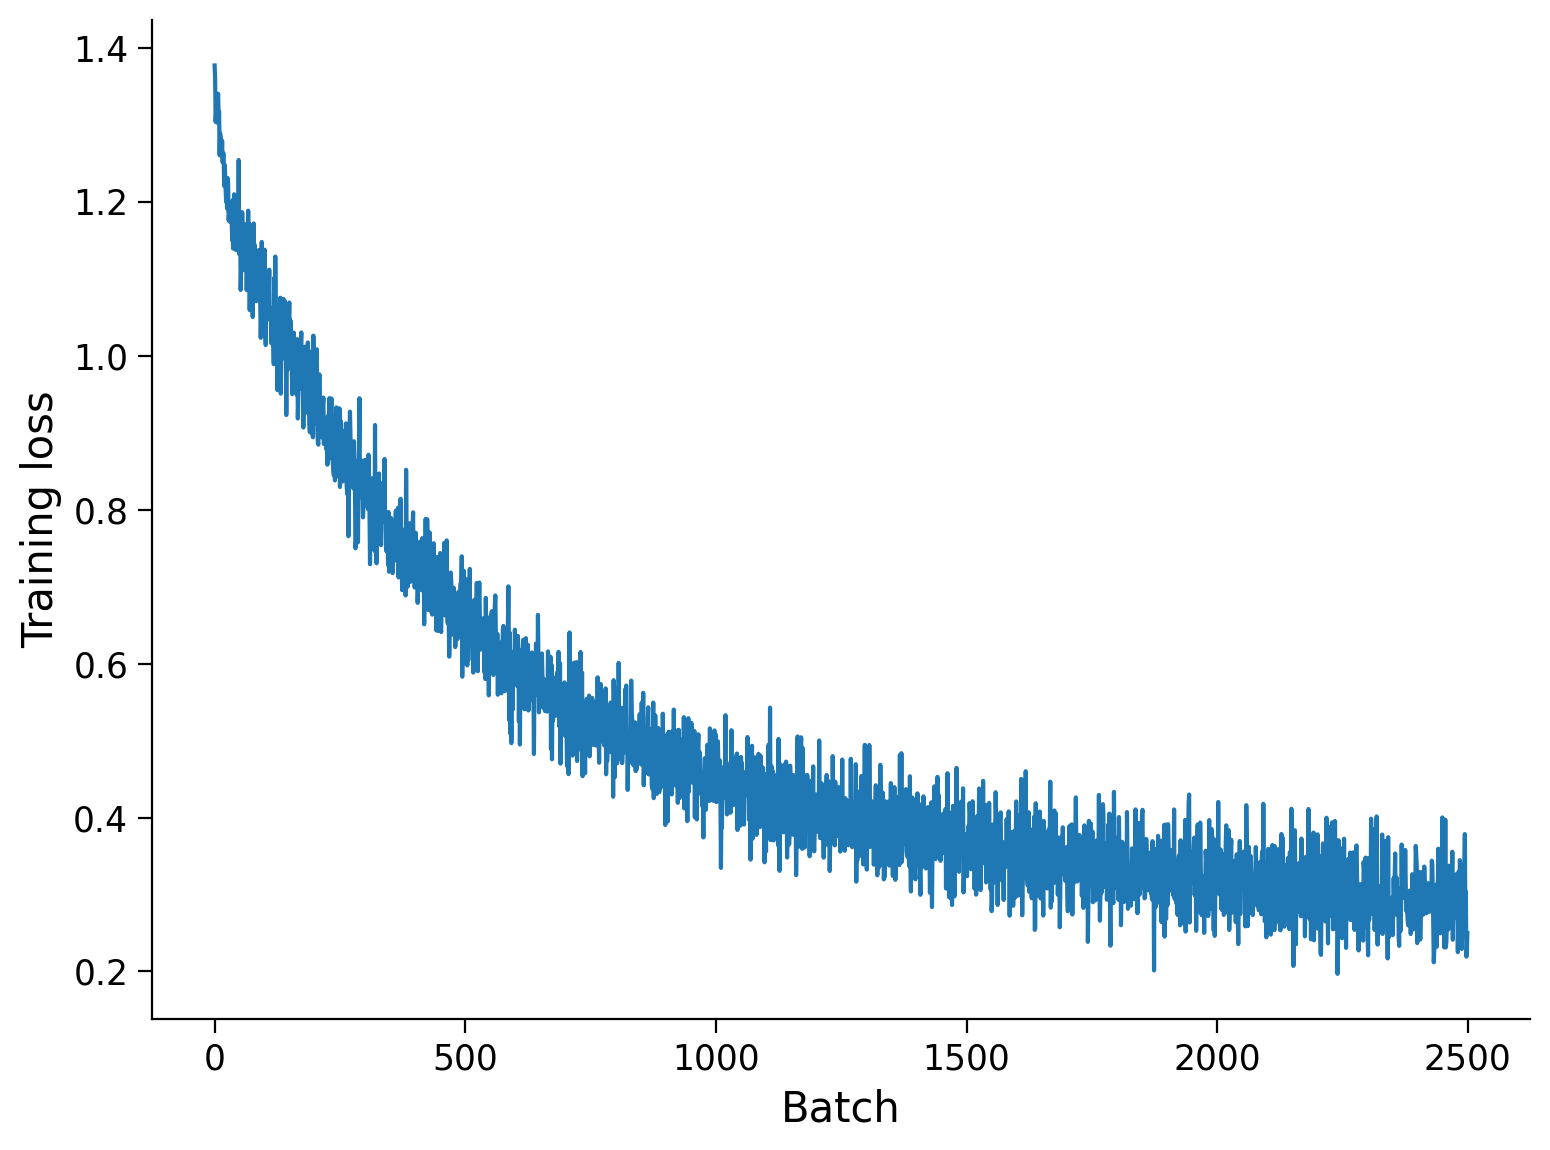

In [32]:
# ============================================================
# IMPOSTAZIONE DEL SEME PER RIPRODUCIBILITÀ
# ============================================================
# Garantisce che ogni esecuzione produca gli stessi risultati
# I numeri casuali (inizializzazione pesi, shuffle dati) saranno identici
set_seed(SEED)

# ============================================================
# CREAZIONE DEL MODELLO
# ============================================================
# Crea un'istanza della classe Net con i seguenti parametri:
# - Attivazione: ReLU() - funzione di attivazione non lineare
# - Input size: X_train.shape[1] = 2 (coordinate x e y del dataset a spirale)
# - Hidden units: [128] - UN layer nascosto con 128 neuroni
# - Output size: K = numero di classi (es. 4 per il dataset a spirale)
# .to(DEVICE) sposta il modello su GPU se disponibile, altrimenti su CPU
net = Net('ReLU()', X_train.shape[1], [128], K).to(DEVICE)

# ============================================================
# DEFINIZIONE DELLA FUNZIONE DI LOSS
# ============================================================
# CrossEntropyLoss è la funzione standard per classificazione multi-classe
# Combina due operazioni in modo numericamente stabile:
# 1. Softmax: converte i logits in probabilità
# 2. Negative Log Likelihood: -log(probabilità_classe_corretta)
# Non serve applicare softmax manualmente!
criterion = nn.CrossEntropyLoss()

# ============================================================
# DEFINIZIONE DELL'OTTIMIZZATORE
# ============================================================
# Adam è un ottimizzatore popolare che adatta il learning rate durante il training
# net.parameters() restituisce TUTTI i pesi e bias del modello
# lr=1e-3 = 0.001 è un learning rate tipico per Adam
optimizer = optim.Adam(net.parameters(), lr=1e-3)

# ============================================================
# IMPOSTAZIONE DEL NUMERO DI EPOCH
# ============================================================
# Il modello vedrà l'intero dataset di training 100 volte
# Ogni epoca = una passata completa su tutti i 3200 campioni
num_epochs = 100

# ============================================================
# ADDESTRAMENTO E VALUTAZIONE
# ============================================================
# La funzione train_test_classification:
# 1. Addestra il modello per num_epochs epoche
# 2. Mostra il grafico della loss durante training (training_plot=True)
# 3. Valuta l'accuratezza su training set e test set
# 4. Restituisce le accuratezze (ignorate qui con _ , _ )
_, _ = train_test_classification(
    net,                          # Il modello da addestrare
    criterion,                    # La funzione di loss
    optimizer,                    # L'ottimizzatore
    train_loader,                 # DataLoader con dati di training (batch=128, shuffle)
    test_loader,                   # DataLoader con dati di test (batch=128, no shuffle)
    num_epochs=num_epochs,        # 100 epoche
    training_plot=True,            # Mostra il grafico dell'andamento della loss
    device=DEVICE                  # Esegui su GPU/CPU
)

And finally, let's visualize the learned decision-map. We know you're probably running out of time, so we won't make you write code now! But make sure you have reviewed it since we'll start with another visualization technique next time.

In [53]:
def sample_grid(M=500, x_max=2.0):
  """
  Helper function to simulate sample meshgrid

  Args:
    M: int
      Size of the constructed tensor with meshgrid
    x_max: float
      Defines range for the set of points

  Returns:
    X_all: torch.tensor
      Concatenated meshgrid tensor
  """
  ii, jj = torch.meshgrid(torch.linspace(-x_max, x_max, M),
                          torch.linspace(-x_max, x_max, M),
                          indexing="ij")
  X_all = torch.cat([ii.unsqueeze(-1),
                     jj.unsqueeze(-1)],
                     dim=-1).view(-1, 2)
  return X_all


def plot_decision_map(X_all, y_pred, X_test, y_test,
                      M=500, x_max=2.0, eps=1e-3):
  """
  Helper function to plot decision map

  Args:
    X_all: torch.tensor
      Concatenated meshgrid tensor
    y_pred: torch.tensor
      Labels predicted by the network
    X_test: torch.tensor
      Test data
    y_test: torch.tensor
      Labels of the test data
    M: int
      Size of the constructed tensor with meshgrid
    x_max: float
      Defines range for the set of points
    eps: float
      Decision threshold

  Returns:
    Nothing
  """
  decision_map = torch.argmax(y_pred, dim=1)

  for i in range(len(X_test)):
    indices = (X_all[:, 0] - X_test[i, 0])**2 + (X_all[:, 1] - X_test[i, 1])**2 < eps
    decision_map[indices] = (K + y_test[i]).long()

  decision_map = decision_map.view(M, M)
  plt.imshow(decision_map, extent=[-x_max, x_max, -x_max, x_max], cmap='jet')
  plt.xlabel('x1')
  plt.ylabel('x2')
  plt.show()

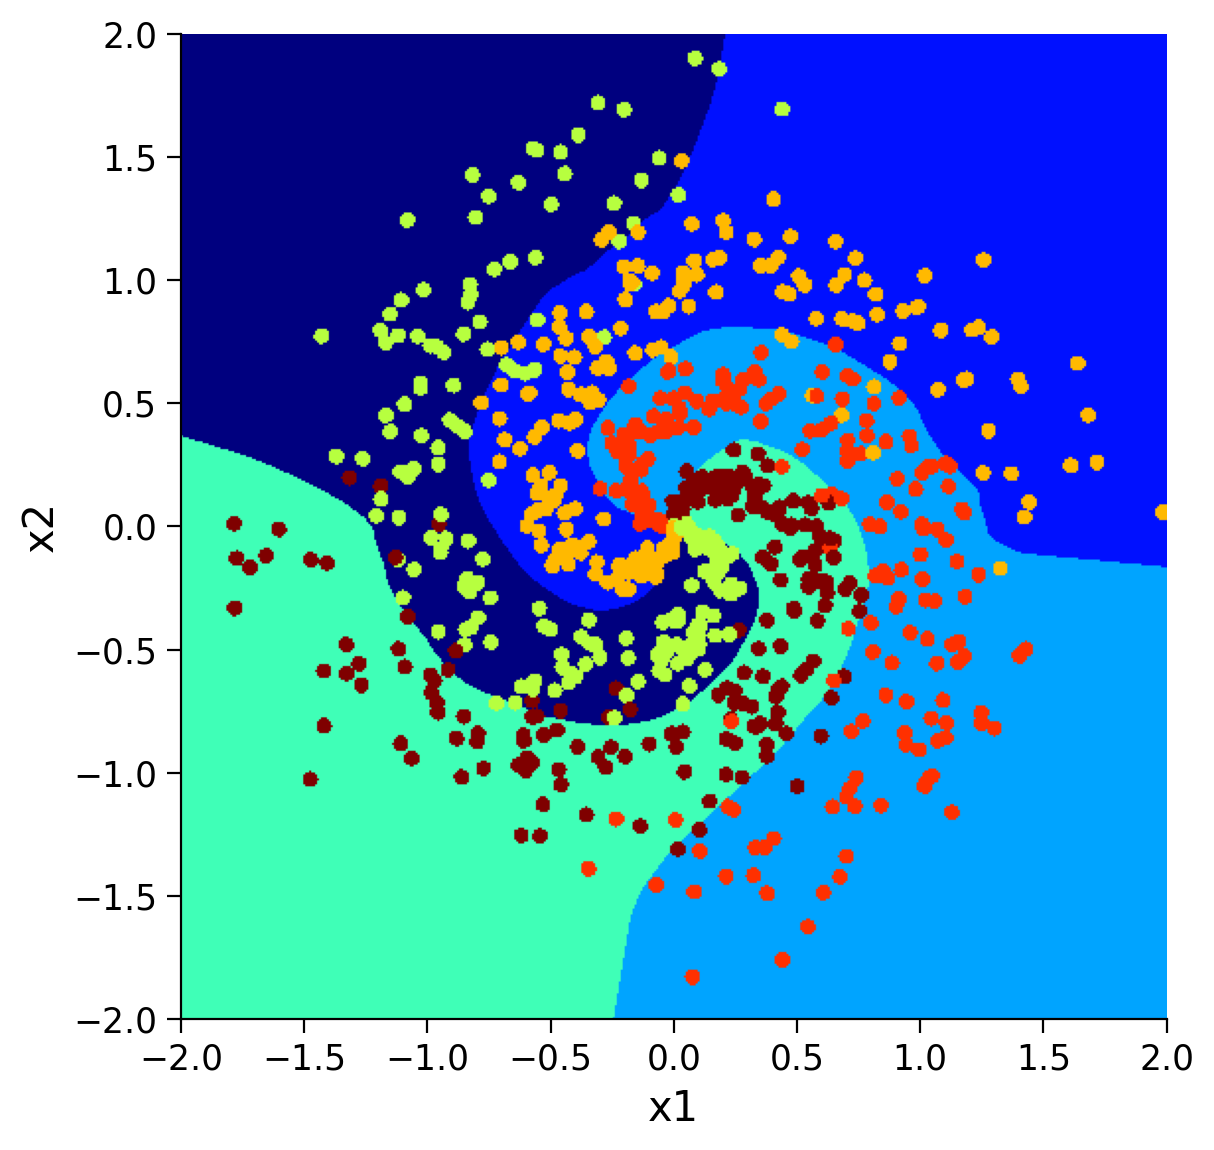

In [54]:
X_all = sample_grid()
y_pred = net(X_all.to(DEVICE)).cpu()
plot_decision_map(X_all, y_pred, X_test, y_test)

### Think! 2.3.2: Does it generalize well?
Do you think this model is performing well outside its training distribution? Why?

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content-dl/tree/main/tutorials/W1D3_MultiLayerPerceptrons/solutions/W1D3_Tutorial1_Solution_47ad29c3.py)



What would be your suggestions to increase models ability to generalize? Think about it and discuss with your pod.

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content-dl/tree/main/tutorials/W1D3_MultiLayerPerceptrons/solutions/W1D3_Tutorial1_Solution_c71914b5.py)



---
# Summary

In this tutorial, we have explored the Multi-leayer Perceptrons (MLPs). More specifically, we have discussed the similarities between artificial and biological neural networks (for more information see the Bonus section). we have also learned the Universal Approximation Theorem and implemented MLPs in PyTorch.

---
# Bonus: Neuron Physiology and Motivation to Deep Learning

This section will motivate one of the most popular nonlinearities in deep learning, the ReLU nonlinearity, by starting from the biophysics of neurons and obtaining the ReLU nonlinearity through a sequence of approximations. We will also show that neuronal biophysics sets a time scale for signal propagation speed through the brain. This time scale implies that neural circuits underlying fast perceptual and motor processing in the brain may not be excessively deep.

In [ ]:
# @title Video 5: Biological to Artificial Neurons
from ipywidgets import widgets
from IPython.display import YouTubeVideo
from IPython.display import IFrame
from IPython.display import display


class PlayVideo(IFrame):
  def __init__(self, id, source, page=1, width=400, height=300, **kwargs):
    self.id = id
    if source == 'Bilibili':
      src = f'https://player.bilibili.com/player.html?bvid={id}&page={page}'
    elif source == 'Osf':
      src = f'https://mfr.ca-1.osf.io/render?url=https://osf.io/download/{id}/?direct%26mode=render'
    super(PlayVideo, self).__init__(src, width, height, **kwargs)


def display_videos(video_ids, W=400, H=300, fs=1):
  tab_contents = []
  for i, video_id in enumerate(video_ids):
    out = widgets.Output()
    with out:
      if video_ids[i][0] == 'Youtube':
        video = YouTubeVideo(id=video_ids[i][1], width=W,
                             height=H, fs=fs, rel=0)
        print(f'Video available at https://youtube.com/watch?v={video.id}')
      else:
        video = PlayVideo(id=video_ids[i][1], source=video_ids[i][0], width=W,
                          height=H, fs=fs, autoplay=False)
        if video_ids[i][0] == 'Bilibili':
          print(f'Video available at https://www.bilibili.com/video/{video.id}')
        elif video_ids[i][0] == 'Osf':
          print(f'Video available at https://osf.io/{video.id}')
      display(video)
    tab_contents.append(out)
  return tab_contents


video_ids = [('Youtube', 'ELAbflymSLo'), ('Bilibili', 'BV1mf4y157vf')]
tab_contents = display_videos(video_ids, W=854, H=480)
tabs = widgets.Tab()
tabs.children = tab_contents
for i in range(len(tab_contents)):
  tabs.set_title(i, video_ids[i][0])
display(tabs)

## Leaky Integrate-and-fire (LIF) neuronal model

The basic idea of LIF neuron was proposed in 1907 by Louis Édouard Lapicque, long before we understood the electrophysiology of a neuron (see a translation of [Lapicque's paper](https://pubmed.ncbi.nlm.nih.gov/17968583/) ). More details of the model can be found in the book [**Theoretical neuroscience**](http://www.gatsby.ucl.ac.uk/~dayan/book/) by Peter Dayan and Laurence F. Abbott.

The model dynamics is defined with the following formula,

\begin{equation}
\frac{d V_m}{d t}=\left\{\begin{array}{cc}
\frac{1}{C_m}\left(-\frac{V_m}{R_m} + I \right) & t>t_{rest} \\
0 & \text { otherwise }
\end{array}\right.
\end{equation}


Note that $V_{m}$, $C_{m}$, and $R_{m}$ are the membrane voltage, capacitance, and resitance of the neuron, respectively, so the $-\frac{V_{m}}{R_{m}}$ denotes the leakage current. When $I$ is sufficiently strong such that $V_{m}$ reaches a certain threshold value $V_{\rm th}$, it momentarily spikes and then $V_{m}$ is reset to $V_{\rm reset}< V_{\rm th}$, and voltage stays at $V_{\rm reset}$ for $\tau_{\rm ref}$ ms, mimicking the refractoriness of the neuron during an action potential (note that $V_{\rm reset}$ and $\tau_{\rm ref}$ is assumed to be zero in the lecture):


\begin{eqnarray}
V_{m}(t)=V_{\rm reset} \text{ for } t\in(t_{\text{sp}}, t_{\text{sp}} + \tau_{\text{ref}}]
\end{eqnarray}


where $t_{\rm sp}$ is the spike time when $V_{m}(t)$ just exceeded $V_{\rm th}$.

Thus, the LIF model captures the fact that a neuron:
- Performs spatial and temporal integration of synaptic inputs
- Generates a spike when the voltage reaches a certain threshold
- Goes refractory during the action potential
- Has a leaky membrane

For in-depth content on computational models of neurons, follow the [NMA](https://www.neuromatchacademy.org/) tutorial 1 of *Biological Neuron Models*. Specifically, for NMA-CN 2021 follow this [Tutorial](https://github.com/NeuromatchAcademy/course-content/blob/master/tutorials/W2D3_BiologicalNeuronModels/W2D3_Tutorial1.ipynb).

## Simulating an LIF Neuron

In the cell below is given a function for LIF neuron model with it's arguments described.

Note that we will use Euler's method to make a numerical approximation to a derivative. Hence we will use the following implementation of the model dynamics,

\begin{equation}
V_m^{[n]}=\left\{\begin{array}{cc}
V_m^{[n-1]} + \frac{1}{C_m}\left(-\frac{V_m^{[n-1]}}{R_m}+I \right) \Delta t & t>t_{r e s t} \\
0 & \text { otherwise }
\end{array}\right.
\end{equation}

where the superscript $[\cdot]$ denotes the time point.

In [ ]:
def run_LIF(I, T=50, dt=0.1, tau_ref=10,
            Rm=1, Cm=10, Vth=1, V_spike=0.5):
  """
  Simulate the LIF dynamics with external input current

  Args:
    I          : int
      Input current (mA)
    T          : int
      Total time to simulate (msec)
    dt         : float
      Simulation of time step (msec)
    tau_ref    : int
      Refractory period (msec)
    Rm         : int
      Resistance (kOhm)
    Cm         : int
      Capacitance (uF)
    Vth        : int
      Spike threshold (V)
    V_spike    : float
      Spike delta (V)

  Returns:
    time       : list
      Time points
    Vm         : list
      Tracking membrane potentials
  """

  # Set up array of time steps
  time = torch.arange(0, T + dt, dt)

  # Set up array for tracking Vm
  Vm = torch.zeros(len(time))

  # Iterate over each time step
  t_rest = 0
  for i, t in enumerate(time):

    # If t is after refractory period
    if t > t_rest:
      Vm[i] = Vm[i-1] + 1/Cm*(-Vm[i-1]/Rm + I)  * dt

    # If Vm is over the threshold
    if Vm[i] >= Vth:

      # Increase volatage by change due to spike
      Vm[i] += V_spike

      # Set up new refactory period
      t_rest = t + tau_ref

  return time, Vm


sim_time, Vm = run_LIF(1.5)
# Plot the membrane voltage across time
plt.plot(sim_time, Vm)
plt.title('LIF Neuron Output')
plt.ylabel('Membrane Potential (V)')
plt.xlabel('Time (msec)')
plt.show()

### Interactive Demo: Neuron's transfer function explorer for different $R_m$ and $\tau_{ref}$
We know that real neurons communicate by modulating the spike count meaning that more input current causes a neuron to spike more often. Therefore, to find an input-output relationship, it makes sense to characterize their spike count as a function of input current. This is called the neuron's input-output transfer function. Let's plot the neuron's transfer function and see how it changes with respect to the **membrane resistance** and **refractory time**?

In [ ]:
# @title

# @markdown Make sure you execute this cell to enable the widget!
my_layout = widgets.Layout()

@widgets.interact(Rm=widgets.FloatSlider(1., min=1, max=100.,
                                         step=0.1, layout=my_layout),
                  tau_ref=widgets.FloatSlider(1., min=1, max=100.,
                                            step=0.1, layout=my_layout)
                  )


def plot_IF_curve(Rm, tau_ref):
  """
  Helper function to plot frequency-current curve

  Args:
    Rm         : int
      Resistance (kOhm)
    tau_ref    : int
      Refractory period (msec)

  Returns:
    Nothing
  """
  T = 1000  # Total time to simulate (msec)
  dt = 1  # Simulation time step (msec)
  Vth = 1  # Spike threshold (V)
  Is_max = 2
  Is = torch.linspace(0, Is_max, 10)
  spike_counts = []
  for I in Is:
    _, Vm = run_LIF(I, T=T, dt=dt, Vth=Vth, Rm=Rm, tau_ref=tau_ref)
    spike_counts += [torch.sum(Vm > Vth)]

  plt.plot(Is, spike_counts)
  plt.title('LIF Neuron: Transfer Function')
  plt.ylabel('Spike count')
  plt.xlabel('I (mA)')
  plt.xlim(0, Is_max)
  plt.ylim(0, 80)
  plt.show()

interactive(children=(FloatSlider(value=1.0, description='Rm', min=1.0), FloatSlider(value=1.0, description='t…

### Think!: Real and Artificial neuron similarities

What happens at infinite membrane resistance ($R_m$) and small refactory time ($\tau_{ref}$)? Why?

Take 10 mins to discuss the similarity between a real neuron and an artificial one with your pod.

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content-dl/tree/main/tutorials/W1D3_MultiLayerPerceptrons/solutions/W1D3_Tutorial1_Solution_23ab5734.py)

